Лабораторная работа 1 Системы ОДУ VIII.11.5

In [127]:
import numpy as np
import matplotlib.pyplot as plt

In [128]:
class Dot(object):
    def __init__(self, coords, t):
        self.coords = coords
        self.t = t

A = 1
B = 3

dt = 0.1
t_min = 0
t_max = 5000

y_0 = Dot(np.array([1, 1]), t_min)

def f(coords: np.array, t: float):
    [u,v] = coords
    return np.array([
        A + v*(u**2) - (B + 1)*u,
        B*u - v*(u**2)
    ])

In [129]:
def Dot_parser(dots):
    t = [dot.t for dot in dots]
    coords = [dot.coords for dot in dots]
    ret = list([t])
    n = len(coords[0])
    for i in range(n):
        ret.append([point[i] for point in coords])
    return ret

In [130]:
def YaMRK_1(dot: Dot, f, dt=dt):
    k1 = dt * f(dot.coords, dot.t)
    return Dot(dot.coords + k1, dot.t + dt)

def YaMRK_2(dot: Dot, f, dt=dt):
    k1 = dt * f(dot.coords, dot.t)
    k2 = dt * f(dot.coords + 0.5 * k1, dot.t + 0.5 * dt)
    return Dot(dot.coords + k2, dot.t + dt)

def YaMRK_3(dot: Dot, f, dt=dt):
    k1 = dt * f(dot.coords, dot.t)
    k2 = dt * f(dot.coords + 0.5 * k1, dot.t + 0.5 * dt)
    k3 = dt * f(dot.coords - k1 + 2 * k2, dot.t + dt)
    return Dot(dot.coords + 1/6 * (k1 + 4*k2 + k3), dot.t + dt)

def YaMRK_4(dot: Dot, f, dt=dt):
    k1 = dt * f(dot.coords, dot.t)
    k2 = dt * f(dot.coords + 0.5 * k1, dot.t + 0.5 * dt)
    k3 = dt * f(dot.coords + 0.5 * k2, dot.t + 0.5 * dt)
    k4 = dt * f(dot.coords + k3, dot.t + dt)
    return Dot(dot.coords + 1/6 * (k1 + 2*k2 + 2*k3 + k4), dot.t + dt)

YaMRK_RankIterMethod = {
    1 : YaMRK_1,
    2 : YaMRK_2,
    3 : YaMRK_3,
    4 : YaMRK_4
}

def YaMRK(dot: Dot, f, dt=dt, rank=4):
    ret = list()
    method = YaMRK_RankIterMethod[rank]
    while dot.t <= t_max:
        ret.append(dot)
        dot = method(dot, f, dt)
    return ret

/tmp/ipykernel_69229/1266683547.py:18: RuntimeWarning: overflow encountered in scalar power
  A + v*(u**2) - (B + 1)*u,
/tmp/ipykernel_69229/1266683547.py:19: RuntimeWarning: overflow encountered in scalar power
  B*u - v*(u**2)
/tmp/ipykernel_69229/3016872943.py:3: RuntimeWarning: invalid value encountered in add
  return Dot(dot.coords + k1, dot.t + dt)
/tmp/ipykernel_69229/1266683547.py:18: RuntimeWarning: overflow encountered in scalar multiply
  A + v*(u**2) - (B + 1)*u,
/tmp/ipykernel_69229/1266683547.py:19: RuntimeWarning: overflow encountered in scalar multiply
  B*u - v*(u**2)
/tmp/ipykernel_69229/3016872943.py:7: RuntimeWarning: invalid value encountered in add
  k2 = dt * f(dot.coords + 0.5 * k1, dot.t + 0.5 * dt)
/tmp/ipykernel_69229/3016872943.py:14: RuntimeWarning: invalid value encountered in add
  return Dot(dot.coords + 1/6 * (k1 + 4*k2 + k3), dot.t + dt)
/tmp/ipykernel_69229/3016872943.py:18: RuntimeWarning: invalid value encountered in add
  k2 = dt * f(dot.coords + 

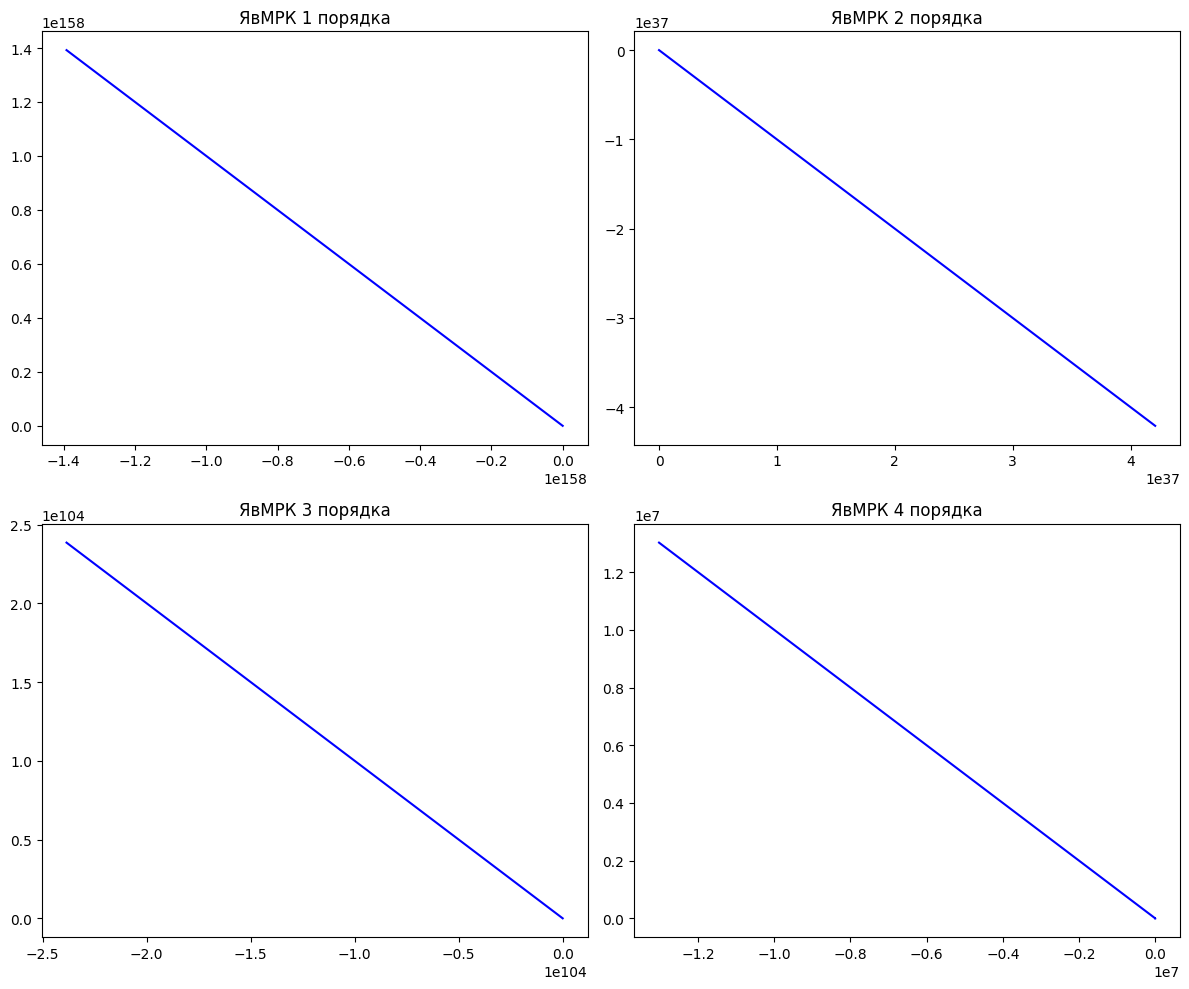

In [131]:
fig = plt.figure(figsize=(12, 10))

res = Dot_parser(YaMRK(y_0, f, rank=1))
ax = fig.add_subplot(221)
ax.set_title("ЯвМРК 1 порядка")
ax.plot(res[1], res[2], color='blue')

# Второй график
res = Dot_parser(YaMRK(y_0, f, rank=2))
ax = fig.add_subplot(222)
ax.set_title("ЯвМРК 2 порядка")
ax.plot(res[1], res[2], color='blue')

# Третий график
res = Dot_parser(YaMRK(y_0, f, rank=3))
ax = fig.add_subplot(223)
ax.set_title("ЯвМРК 3 порядка")
ax.plot(res[1], res[2], color='blue')

# Четвёртый график
res = Dot_parser(YaMRK(y_0, f, rank=4))
ax = fig.add_subplot(224)
ax.set_title("ЯвМРК 4 порядка")
ax.plot(res[1], res[2], color='blue')

plt.tight_layout()
plt.show()

In [132]:
def YaAdams_2(f_val, dot: Dot, dt=dt):
    i = len(f_val) - 1
    return Dot(dot.coords + dt * (3*f_val[i] - f_val[i-1]) / 2, dot.t + dt)

def YaAdams_3(f_val, dot: Dot, dt=dt):
    i = len(f_val) - 1
    return Dot(dot.coords + dt * (23*f_val[i] - 16*f_val[i-1] + 5*f_val[i-2]) / 12, dot.t + dt)

def YaAdams_4(f_val, dot: Dot, dt=dt):
    i = len(f_val) - 1
    return Dot(dot.coords + dt * (55*f_val[i] - 59*f_val[i-1] + 37*f_val[i-2] - 9*f_val[i-3]) / 24, dot.t + dt)

YaAdams_RankIterMethod = {
    2 : YaAdams_2,
    3 : YaAdams_3,
    4 : YaAdams_4
}

def YaAdams(dot: Dot, f, dt=dt, rank=2):
    dots = list()
    dots.append(dot)
    f_val = list()
    f_val.append(f(dot.coords, dot.t))

    for i in range(rank):
        dot = YaMRK_4(dots[i], f, dt=dt)
        dots.append(dot)
        f_val.append(f(dot.coords, dot.t))

    method = YaAdams_RankIterMethod[rank]
    while dot.t <= t_max:
        dot = method(f_val, dot, dt=dt)
        dots.append(dot)
        f_val.append(f(dot.coords, dot.t))

    return dots

/tmp/ipykernel_69229/1266683547.py:18: RuntimeWarning: overflow encountered in scalar power
  A + v*(u**2) - (B + 1)*u,
/tmp/ipykernel_69229/1266683547.py:19: RuntimeWarning: overflow encountered in scalar power
  B*u - v*(u**2)
/tmp/ipykernel_69229/1147978711.py:3: RuntimeWarning: invalid value encountered in add
  return Dot(dot.coords + dt * (3*f_val[i] - f_val[i-1]) / 2, dot.t + dt)
/tmp/ipykernel_69229/1147978711.py:7: RuntimeWarning: invalid value encountered in add
  return Dot(dot.coords + dt * (23*f_val[i] - 16*f_val[i-1] + 5*f_val[i-2]) / 12, dot.t + dt)
/tmp/ipykernel_69229/3016872943.py:18: RuntimeWarning: invalid value encountered in add
  k2 = dt * f(dot.coords + 0.5 * k1, dot.t + 0.5 * dt)


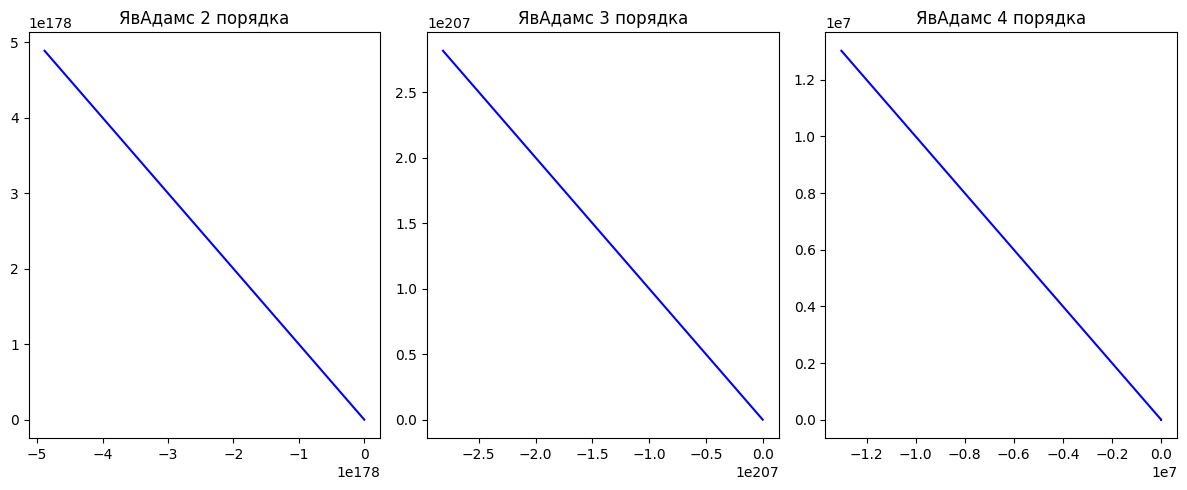

In [133]:
fig = plt.figure(figsize=(12, 5))

res = Dot_parser(YaAdams(y_0, f, rank=2))
ax = fig.add_subplot(131)
ax.set_title("ЯвАдамс 2 порядка")
ax.plot(res[1], res[2], color='blue')

res = Dot_parser(YaAdams(y_0, f, rank=3))
ax = fig.add_subplot(132)
ax.set_title("ЯвАдамс 3 порядка")
ax.plot(res[1], res[2], color='blue')

res = Dot_parser(YaMRK(y_0, f, rank=4))
ax = fig.add_subplot(133)
ax.set_title("ЯвАдамс 4 порядка")
ax.plot(res[1], res[2], color='blue')

plt.tight_layout()
plt.show()

In [134]:
def DfBack_2(f, dots, dt=dt):
    i = len(dots) - 1
    return Dot((4/3) * dots[i].coords - (1/3) * dots[i-1].coords + (2/3) * dt * f(dots[i].coords, dots[i].t), dots[i].t + dt)

def DfBack_3(f, dots, dt=dt):
    i = len(dots) - 1
    return Dot((18/11) * dots[i].coords - (9/11) * dots[i-1].coords + (2/11) * dots[i-2].coords + (6/11) * dt * f(dots[i].coords, dots[i].t), dots[i].t + dt)

def DfBack_4(f, dots, dt=dt):
    i = len(dots) - 1
    return Dot((48/25) * dots[i].coords - (36/25) * dots[i-1].coords + (16/25) * dots[i-2].coords - (3/25) * dots[i-3].coords + (12/25) * dt * f(dots[i].coords, dots[i].t), dots[i].t + dt)

DfBack_RankIterMethod = {
    2 : DfBack_2,
    3 : DfBack_3,
    4 : DfBack_4
}

def DfBack(dot: Dot, f, dt=dt, rank=2):
    dots = list()
    dots.append(dot)

    for i in range(rank):
        dot = YaMRK_4(dots[i], f, dt=dt)
        dots.append(dot)

    method = DfBack_RankIterMethod[rank]
    while dot.t <= t_max:
        dot = method(f, dots, dt=dt)
        dots.append(dot)

    return dots

/tmp/ipykernel_69229/1266683547.py:18: RuntimeWarning: overflow encountered in scalar power
  A + v*(u**2) - (B + 1)*u,
/tmp/ipykernel_69229/1266683547.py:19: RuntimeWarning: overflow encountered in scalar power
  B*u - v*(u**2)
/tmp/ipykernel_69229/4144362087.py:3: RuntimeWarning: invalid value encountered in add
  return Dot((4/3) * dots[i].coords - (1/3) * dots[i-1].coords + (2/3) * dt * f(dots[i].coords, dots[i].t), dots[i].t + dt)
/tmp/ipykernel_69229/4144362087.py:7: RuntimeWarning: invalid value encountered in add
  return Dot((18/11) * dots[i].coords - (9/11) * dots[i-1].coords + (2/11) * dots[i-2].coords + (6/11) * dt * f(dots[i].coords, dots[i].t), dots[i].t + dt)
/tmp/ipykernel_69229/1266683547.py:18: RuntimeWarning: overflow encountered in scalar multiply
  A + v*(u**2) - (B + 1)*u,
/tmp/ipykernel_69229/1266683547.py:19: RuntimeWarning: overflow encountered in scalar multiply
  B*u - v*(u**2)
/tmp/ipykernel_69229/4144362087.py:11: RuntimeWarning: invalid value encountered i

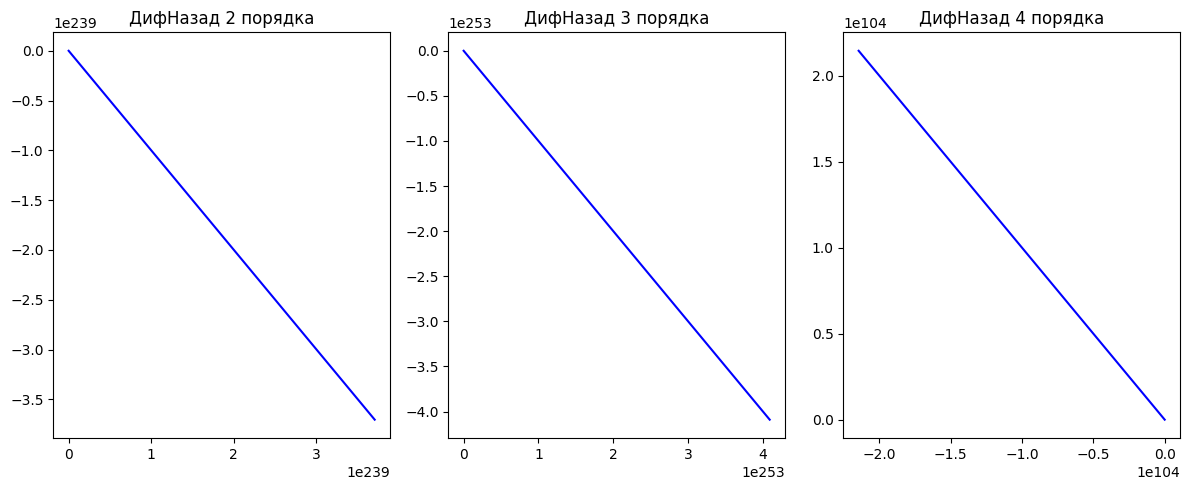

In [135]:
fig = plt.figure(figsize=(12, 5))

res = Dot_parser(DfBack(y_0, f, rank=2))
ax = fig.add_subplot(131)
ax.set_title("ДифНазад 2 порядка")
ax.plot(res[1], res[2], color='blue')

# Третий график
res = Dot_parser(DfBack(y_0, f, rank=3))
ax = fig.add_subplot(132) 
ax.set_title("ДифНазад 3 порядка")
ax.plot(res[1], res[2], color='blue')

# Четвёртый график
res = Dot_parser(DfBack(y_0, f, rank=4))
ax = fig.add_subplot(133)
ax.set_title("ДифНазад 4 порядка")
ax.plot(res[1], res[2], color='blue')

plt.tight_layout()
plt.show()